### ICE TASK TWO
Conduct data analysis and document the process, including data preparation, analytical procedures, software or tools used, parameters, outputs, and any challenges encountered. Present the data analysis process, supported by tables, figures, performance metrics, and explanations of the analytical procedures. 400–500 words. Submit to your supervisor for comments.

In [1]:
#Import Libraries
import pandas as pd
import numpy as np

### Dataset Loading and Inspection
I subsized the dataset down into a 5 million transactions which is a small portion of the dataset for compatibility for the Jupyter platform because the dataset contained 8GBs worth of transactions

In [2]:
#Loading the Dataset
df = pd.read_csv("HI-Small_Trans.csv")
df

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
#Displaying the first five records
df.head()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


In [4]:
#Checking dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5078345
Number of columns: 11


In [5]:
#Displaying columns names
print("Dataset columns:")
print(df.columns.tolist())

Dataset columns:
['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']


In [6]:
#Inspecting data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           object 
 1   From Bank           int64  
 2   Account             object 
 3   To Bank             int64  
 4   Account.1           object 
 5   Amount Received     float64
 6   Receiving Currency  object 
 7   Amount Paid         float64
 8   Payment Currency    object 
 9   Payment Format      object 
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 426.2+ MB


In [7]:
#Checking for missing values
df.isnull().sum()

Timestamp             0
From Bank             0
Account               0
To Bank               0
Account.1             0
Amount Received       0
Receiving Currency    0
Amount Paid           0
Payment Currency      0
Payment Format        0
Is Laundering         0
dtype: int64

In [8]:
#Checking for duplicated records
df.duplicated().sum()

np.int64(9)

### Exploratory Data Analysis (EDA)

#### Target Variable Analysis

In [9]:
#Analysing the target variable
print(df["Is Laundering"].value_counts()) #(pandas, 2026)
print(df["Is Laundering"].value_counts(normalize=True) * 100)

Is Laundering
0    5073168
1       5177
Name: count, dtype: int64
Is Laundering
0    99.898057
1     0.101943
Name: proportion, dtype: float64


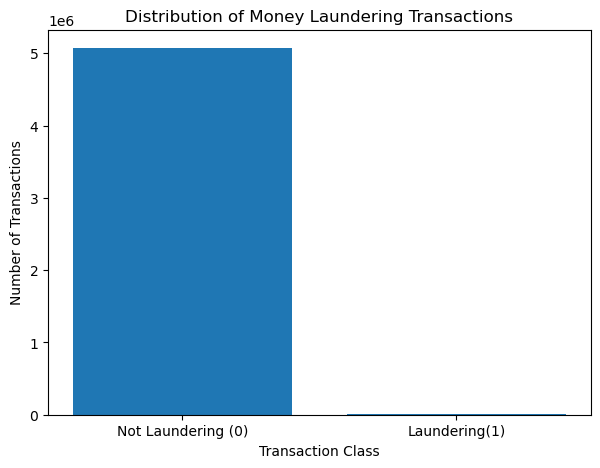

In [10]:
#Visualization for the target variable
import matplotlib.pyplot as plt

#Count the number of laundering and non-laundering transactions
class_counts = df["Is Laundering"].value_counts().sort_index() #(Hunter, 2007)

plt.figure(figsize=(7, 5))
plt.bar(["Not Laundering (0)", "Laundering(1)"], class_counts.values)

plt.title("Distribution of Money Laundering Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.show()

#### Interpretation
The target variable, Is Laundering, was examined to determine the distribution of legitimate and money-laundering transactions. The value_counts() function in pandas was used to calculate the frequency and proportional distribution of each class (pandas, 2026). The analysis identified a substantial class imbalance: 5,073,168 transactions (99.8981%) were classified as non-laundering, while only 5,177 transactions (0.1019%) were labelled as laundering. This imbalance is important when evaluating classification models because conventional accuracy can produce misleadingly high results when the majority class dominates the dataset. Measures such as precision, recall and F1-score are therefore important when assessing the models, while precision-recall analysis is particularly useful for highly imbalanced classification problems (scikit-learn developers, 2026).

#### Numerical Variables (Transaction Amount Analysis)

In [11]:
#Descriptive statistics for numerical variables

df[["Amount Received", "Amount Paid"]].describe() #(pandas, 2026)

,Amount Received,Amount Paid
count,5.078345e+06,5.078345e+06
mean,5.988726e+06,4.509273e+06
std,1.037183e+09,8.697728e+08
min,1.000000e-06,1.000000e-06
25%,1.833700e+02,1.844800e+02
50%,1.411010e+03,1.414540e+03
75%,1.234627e+04,1.229784e+04
max,1.046302e+12,1.046302e+12


In [12]:
# Comparing transaction amounts between laundering and non-laundering transactions

df.groupby("Is Laundering")[["Amount Received", "Amount Paid"]].agg(
    ["count", "mean", "median", "min", "max"]
)

Amount Received                                                 \
                        count          mean   median       min           max   
Is Laundering                                                                  
0                     5073168  5.957962e+06  1407.51  0.000001  1.046302e+12   
1                        5177  3.613531e+07  8667.21  0.003227  8.485314e+10   

              Amount Paid                                                 
                    count          mean   median       min           max  
Is Laundering                                                             
0                 5073168  4.477000e+06  1410.99  0.000001  1.046302e+12  
1                    5177  3.613531e+07  8667.21  0.003227  8.485314e+10

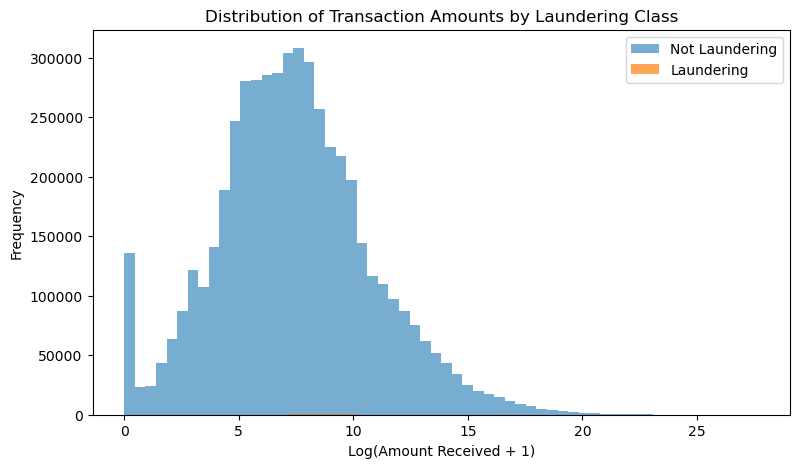

In [13]:
# Log transformation for visualisation

df["Log Amount Received"] = np.log1p(df["Amount Received"]) #(NumPy Developers, 2026)

plt.figure(figsize=(9, 5))

plt.hist(
    df.loc[df["Is Laundering"] == 0, "Log Amount Received"],
    bins=60,
    alpha=0.6,
    label="Not Laundering"
)

plt.hist(
    df.loc[df["Is Laundering"] == 1, "Log Amount Received"],
    bins=60,
    alpha=0.7,
    label="Laundering"
)

plt.title("Distribution of Transaction Amounts by Laundering Class")
plt.xlabel("Log(Amount Received + 1)")
plt.ylabel("Frequency")
plt.legend()

plt.show()

#### Interpretation
Descriptive statistics were generated for Amount Received and Amount Paid to examine their distributions and identify differences between legitimate and laundering transactions. The results showed substantial positive skewness, with the mean transaction amounts considerably exceeding their respective medians. For example, the overall mean amount received was approximately 5.99 million, compared with a median of approximately 1,411. Laundering transactions also recorded a substantially higher median amount received of approximately 8,667 compared with approximately 1,408 for legitimate transactions. A logarithmic transformation was therefore applied for visualisation using NumPy's log1p() function, which calculates the natural logarithm of one plus each value (NumPy Developers, 2026). Log transformation reduces the visual influence of extremely large values and enables the underlying transaction distribution to be examined more clearly.

#### Categorical Variables Analysis

In [14]:
#Examining categorical variables using pandas frequency analysis
categorical_columns = [  #(pandas, 2026)
    "Receiving Currency",
    "Payment Currency",
    "Payment Format"
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print("Number of unique values:", df[column].nunique())
    print("\nTop values:")
    print(df[column].value_counts().head(10))


--- Receiving Currency ---
Number of unique values: 15

Top values:
Receiving Currency
US Dollar      1879341
Euro           1172017
Swiss Franc     237884
Yuan            206551
Shekel          194988
Rupee           192065
UK Pound        181255
Ruble           157361
Yen             156319
Bitcoin         148151
Name: count, dtype: int64

--- Payment Currency ---
Number of unique values: 15

Top values:
Payment Currency
US Dollar      1895172
Euro           1168297
Swiss Franc     234860
Yuan            213752
Shekel          192184
Rupee           190202
UK Pound        180738
Yen             155209
Ruble           155178
Bitcoin         146066
Name: count, dtype: int64

--- Payment Format ---
Number of unique values: 7

Top values:
Payment Format
Cheque          1864331
Credit Card     1323324
ACH              600797
Cash             490891
Reinvestment     481056
Wire             171855
Bitcoin          146091
Name: count, dtype: int64


In [15]:
# Comparing the proportional distribution of laundering transactions across payments formats using pandas

payment_format_analysis = pd.crosstab(
    df["Payment Format"],
    df["Is Laundering"],
    normalize="index"
) * 100

payment_format_analysis

Is Laundering,0,1
Payment Format,,
ACH,99.253825,0.746175
Bitcoin,99.961668,0.038332
Cash,99.977999,0.022001
Cheque,99.982621,0.017379
Credit Card,99.984433,0.015567
Reinvestment,100.000000,0.000000
Wire,100.000000,0.000000


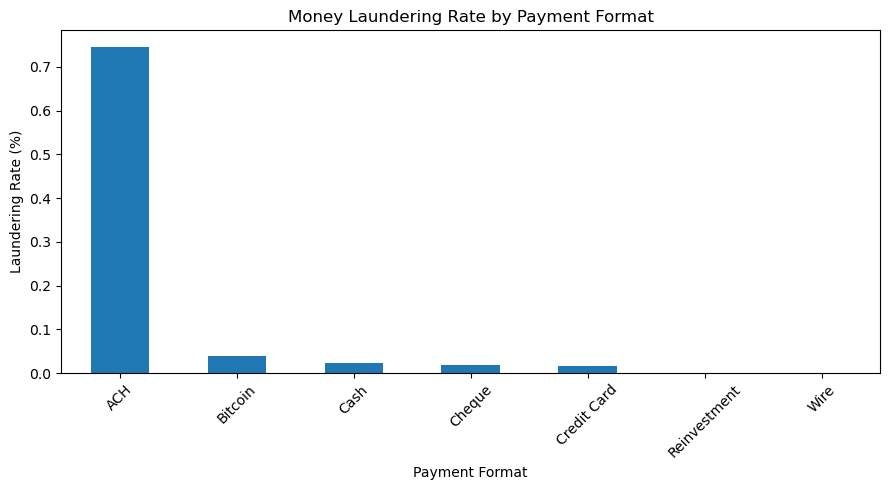

In [16]:
# Visualizing laundering rates by payment format

payment_laundering_rate = (
    df.groupby("Payment Format")["Is Laundering"].mean() * 100
).sort_values(ascending=False)

plt.figure(figsize=(9, 5))

payment_laundering_rate.plot(kind="bar")

plt.title("Money Laundering Rate by Payment Format")
plt.xlabel("Payment Format")
plt.ylabel("Laundering Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Interpretation
The categorical variables Receiving Currency, Payment Currency and Payment Format were examined using frequency counts to identify the number and distribution of categories. Frequency analysis is supported through pandas functions such as value_counts(), which return counts of distinct observations and can also calculate proportions (pandas, 2026). The analysis identified 15 receiving currencies, 15 payment currencies and seven payment formats. Payment format showed noticeable differences in laundering rates, with ACH transactions recording the highest laundering proportion of approximately 0.746%, compared with the overall dataset laundering rate of approximately 0.102%. These findings suggest that payment format could provide useful information during subsequent machine-learning classification. However, because the IBM AML dataset is synthetically generated, these patterns should be interpreted as relationships within the dataset rather than evidence that particular payment methods cause money laundering.

#### Temporal Analysis

In [17]:
# Converting Timestamp to datetime format using pandas
df["Timestamp"] = pd.to_datetime(df["Timestamp"])  # (pandas, 2026)

print("Timestamp data type:", df["Timestamp"].dtype)

print("\nDataset time period:")
print("Start:", df["Timestamp"].min())
print("End:", df["Timestamp"].max())

Timestamp data type: datetime64[ns]

Dataset time period:
Start: 2022-09-01 00:00:00
End: 2022-09-18 16:18:00


In [18]:
# Extracting temporal features from the Timestamp variable using pandas datetime functionality

df["Hour"] = df["Timestamp"].dt.hour #(pandas, 2026)
df["Day"] = df["Timestamp"].dt.day
df["DayOfWeek"] = df["Timestamp"].dt.dayofweek

#### Intepretation
The Timestamp variable was initially stored as an object and was converted into a datetime format using the pandas to_datetime() function. Converting the variable enables temporal characteristics such as hour, day and day of the week to be extracted and potentially used as features during subsequent machine-learning analysis (pandas, 2026). Temporal variables may therefore provide additional information about transaction behaviour without requiring the original timestamp string to be supplied directly to the classification algorithms.

### Data Cleaning & Preprocessing

#### Removing Duplicate Records

In [19]:
#Removing exact duplicate records using Python and pandas
print("Shape before removing duplicates:", df.shape) #(W3Schools)

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)
print("Remaining duplicates:", df.duplicated().sum())

Shape before removing duplicates: (5078345, 15)
Shape after removing duplicates: (5078336, 15)
Remaining duplicates: 0


##### Interpretation
Data cleaning was performed before model development to improve the quality and consistency of the dataset. The initial inspection identified nine exact duplicate records. Duplicate observations can unnecessarily repeat identical information during analysis and were therefore removed before model training. The drop_duplicates() function was used to remove the duplicated observations, after which the dataset dimensions and remaining duplicate count were verified

#### Timestamp Conversion and Feature Engineering
Machine learning algorithms cannot use the raw timestamp string so I have to convert it to datetime and exact Hour and DayOfWeek. 

In [20]:
#Converting Timestamp to datetime

df["Timestamp"] = pd.to_datetime(df["Timestamp"])

#Extract useful temporal features
df["Hour"] = df["Timestamp"].dt.hour
df["DayOfWeek"] = df["Timestamp"].dt.dayofweek

#Remove original timestap
df = df.drop(columns=["Timestamp"])

df[["Hour", "DayOfWeek"]].head()

,Hour,DayOfWeek
0,0,3
1,0,3
2,0,3
3,0,3
4,0,3


##### Interpretation
The Timestamp variable was converted from an object data type into datetime format using pd.to_datetime(). Datetime conversion enables individual temporal characteristics to be extracted from the original timestamp (pandas, 2026). Two features, Hour and DayOfWeek, were retained to provide the classification models with information about when transactions occurred without supplying the original timestamp directly. The original Timestamp variable was subsequently removed from the modelling dataset.

#### Log Transformation of Transaction Amounts

In [21]:
# Log transformation of highly skewed transaction amounts
df["Log Amount Received"] = np.log1p(df["Amount Received"]) # (NumPy Developers, 2026)
df["Log Amount Paid"] = np.log1p(df["Amount Paid"])

# Remove original highly skewed amount columns
df = df.drop(columns=["Amount Received", "Amount Paid"])

df[["Log Amount Received", "Log Amount Paid"]].describe()

,Log Amount Received,Log Amount Paid
count,5.078336e+06,5.078336e+06
mean,7.419110e+00,7.415612e+00
std,3.386979e+00,3.369456e+00
min,9.999995e-07,9.999995e-07
25%,5.216945e+00,5.222947e+00
50%,7.252791e+00,7.255288e+00
75%,9.421193e+00,9.417285e+00
max,2.767628e+01,2.767628e+01


##### Intepretation
The exploratory analysis showed that Amount Received and Amount Paid were highly positively skewed, with extreme transaction values substantially increasing their means relative to their medians. A logarithmic transformation was therefore applied using NumPy's log1p() function, which calculates the natural logarithm of one plus each value (NumPy Developers, 2026). The transformed variables reduce the influence of extremely large numerical scales while preserving the ordering of transaction amounts. The original amount variables were subsequently excluded to avoid retaining both the original and transformed representations.

#### Defining Features and Target Variable

In [22]:
# Defining the target variable

y = df["Is Laundering"]

# Defining the predictor variables
# Account identifiers are excluded from modelling

X = df.drop(
    columns=[
        "Is Laundering",
        "Account",
        "Account.1"
    ]
)

print("Predictor dimensions:", X.shape)
print("Target dimensions:", y.shape)

print("\nPredictor variables:")
print(X.columns.tolist())

Predictor dimensions: (5078336, 10)
Target dimensions: (5078336,)

Predictor variables:
['From Bank', 'To Bank', 'Receiving Currency', 'Payment Currency', 'Payment Format', 'Log Amount Received', 'Hour', 'Day', 'DayOfWeek', 'Log Amount Paid']


##### Interpretation
The Is Laundering variable was defined as the target variable for binary classification, where 0 represents a non-laundering transaction and 1 represents a laundering transaction. Transaction characteristics were retained as predictor variables. The individual Account and Account.1 identifiers were excluded because these fields identify specific accounts rather than general transactional characteristics. Including high-cardinality account identifiers could substantially increase model dimensionality after categorical encoding and encourage models to learn account-specific patterns rather than more generalisable transaction characteristics.

#### Train/Test Split

In [23]:
# Create training and testing datasets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( # (scikit-learn developers, 2026)
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting class distribution:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True) * 100)

Training set: (4062668, 10)
Testing set: (1015668, 10)

Training class distribution:
Is Laundering
0    4058526
1       4142
Name: count, dtype: int64
Is Laundering
0    99.898047
1     0.101953
Name: proportion, dtype: float64

Testing class distribution:
Is Laundering
0    1014633
1       1035
Name: count, dtype: int64
Is Laundering
0    99.898097
1     0.101903
Name: proportion, dtype: float64


##### Interpretation
The dataset was divided into training and testing subsets using an 80:20 split. A fixed random_state=42 was specified to ensure that the experiment could be reproduced. Stratified sampling was performed using the Is Laundering target variable so that the severe class imbalance identified during EDA was proportionally represented in both the training and testing datasets (scikit-learn developers, 2026). The test dataset was kept separate from subsequent majority-class undersampling so that the models could ultimately be evaluated against the original class distribution.

#### Handeling Class Imbalance and Dataset Size

Training SVM directly on millions of observations would also be computationally demanding. The original SVM literature describes support-vector networks as constructing decision surfaces for two-group classification problems (Cortes and Vapnik, 1995). Therefore a controlled undersampling on the trainig data only would need to be performed.

In [24]:
# Creating a controlled modelling training sample

train_data = X_train.copy()
train_data["Is Laundering"] = y_train.values

# Separate minority and majority classes
train_laundering = train_data[
    train_data["Is Laundering"] == 1
]

train_legitimate = train_data[
    train_data["Is Laundering"] == 0
]

print("Laundering training records:", len(train_laundering))
print("Legitimate training records:", len(train_legitimate))

Laundering training records: 4142
Legitimate training records: 4058526


In [25]:
# Controlled majority-class undersampling
# random_state ensures reproducibility

n_legitimate = min(
    len(train_legitimate),
    len(train_laundering) * 10
)

train_legitimate_sample = train_legitimate.sample(
    n=n_legitimate,
    random_state=42
)

# Combine laundering observations with sampled legitimate observations
train_balanced = pd.concat(
    [train_laundering, train_legitimate_sample]
)

# Shuffle the resulting training dataset
train_balanced = train_balanced.sample(
    frac=1,
    random_state=42
)

X_train_model = train_balanced.drop(
    columns=["Is Laundering"]
)

y_train_model = train_balanced[
    "Is Laundering"
]

print("Modelling training set:", X_train_model.shape)

print("\nModelling class counts:")
print(y_train_model.value_counts())

print("\nModelling class percentages:")
print(y_train_model.value_counts(normalize=True) * 100)

Modelling training set: (45562, 10)

Modelling class counts:
Is Laundering
0    41420
1     4142
Name: count, dtype: int64

Modelling class percentages:
Is Laundering
0    90.909091
1     9.090909
Name: proportion, dtype: float64


##### Interpretation
The dataset exhibited severe class imbalance, with laundering transactions accounting for approximately 0.102% of all observations. Furthermore, training all three algorithms—particularly Support Vector Machine—using several million observations would introduce substantial computational requirements. Controlled random undersampling was therefore applied only to the training dataset. All available laundering observations in the training data were retained, while legitimate transactions were randomly sampled at a ratio of approximately 10 legitimate transactions for every laundering transaction. A fixed random state was used to ensure reproducibility. Importantly, the test dataset was not undersampled and retained its original class distribution, enabling model performance to be evaluated under conditions representative of the original dataset

#### Encoding and Feature Scaling

##### Defining Variable groups

In [26]:
#Identify numerical and categorical predictors

numerical_features = [
    "From Bank",
    "To Bank",
    "Hour",
    "DayOfWeek",
    "Log Amount Received",
    "Log Amount Paid"
]

categorical_features = [
    "Receiving Currency",
    "Payment Currency",
    "Payment Format"
]

print("Numerical features:", numerical_features)
print("\nCategorical features:", categorical_features)

Numerical features: ['From Bank', 'To Bank', 'Hour', 'DayOfWeek', 'Log Amount Received', 'Log Amount Paid']

Categorical features: ['Receiving Currency', 'Payment Currency', 'Payment Format']


##### Logistic Regression and SVM preprocessing

In [27]:
# Preprocessing for Logistic Regression and SVM

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

linear_preprocessor = ColumnTransformer( # (scikit-learn developers, 2026)
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

linear_preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


##### Interpretation
The dataset contains both numerical and categorical predictors. Categorical variables were converted into numerical representations using one-hot encoding, allowing the classification algorithms to process variables such as currency and payment format. Numerical features were standardised for Logistic Regression and SVM using StandardScaler, which centres variables according to their mean and scales them according to their standard deviation (scikit-learn developers, 2026). Scaling is particularly relevant when algorithms are affected by differences in feature magnitude. A ColumnTransformer was used to apply the appropriate preprocessing operation to each variable type within a consistent modelling pipeline<!--  -->

##### Random Forest preprocessing

In [28]:
# Preprocessing pipeline for Random Forest

rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

rf_preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


##### One Final Output

In [29]:
# Final preprocessing verification

print("Original dataset:", df.shape)
print("Model training predictors:", X_train_model.shape)
print("Model training target:", y_train_model.shape)
print("Test predictors:", X_test.shape)
print("Test target:", y_test.shape)

print("\nTraining class distribution:")
print(y_train_model.value_counts())

print("\nOriginal test class distribution:")
print(y_test.value_counts())

Original dataset: (5078336, 13)
Model training predictors: (45562, 10)
Model training target: (45562,)
Test predictors: (1015668, 10)
Test target: (1015668,)

Training class distribution:
Is Laundering
0    41420
1     4142
Name: count, dtype: int64

Original test class distribution:
Is Laundering
0    1014633
1       1035
Name: count, dtype: int64


### Logistic Regression

#### Building the Logistic Regression Pipeline

In [30]:
#Build Logistic Regression pipeline

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(  # (scikit-learn developers, 2026)
    steps=[
        ("preprocessor", linear_preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_model

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


##### Interpretation
Logistic Regression was selected as the baseline classification algorithm for predicting whether a transaction was associated with money laundering. Logistic Regression estimates the probability of a binary outcome and provides a useful benchmark against which more complex classification algorithms can be compared. The scikit-learn implementation applies regularisation by default and supports probability estimates for classification (scikit-learn developers, 2026). Since Logistic Regression can be affected by differences in numerical feature scales, the preprocessing pipeline developed previously was applied to standardise numerical variables and one-hot encode categorical variables before classification.

In [31]:
#Training the Logistic Regression model
logistic_model.fit(
    X_train_model,
    y_train_model
)

print("Logistic Regression training completed successfully.")

Logistic Regression training completed successfully.


#### Generating Predictions

In [32]:
# Generate class predictions

y_pred_lr = logistic_model.predict(X_test)

# Generate probability estimates for the laundering class
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions completed.")

Predictions completed.


#### Calculate Performance Metrics

In [33]:
# Calculate Logistic Regression performance metrics

from sklearn.metrics import ( # (scikit-learn developers, 2026)

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-score:  {lr_f1:.4f}")
print(f"ROC-AUC:   {lr_roc_auc:.4f}")

Logistic Regression Performance
--------------------------------
Accuracy:  0.9773
Precision: 0.0156
Recall:    0.3430
F1-score:  0.0299
ROC-AUC:   0.9202


##### Interpretation
Model performance was evaluated using accuracy, precision, recall, F1-score and ROC-AUC. Although accuracy represents the overall proportion of correct classifications, it must be interpreted cautiously because of the substantial class imbalance in the AML dataset. Precision measures the proportion of predicted laundering transactions that were correctly classified, while recall measures the proportion of actual laundering transactions successfully detected. The F1-score represents the harmonic mean of precision and recall (scikit-learn developers, 2026). ROC-AUC was additionally calculated from predicted probabilities to assess the model's ability to distinguish between the two classes across classification thresholds.

#### Classification Report

In [34]:
# Detailed classification report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=[
            "Not Laundering",
            "Laundering"
        ],
        digits=4
    )
)

                precision    recall  f1-score   support

Not Laundering     0.9993    0.9780    0.9885   1014633
    Laundering     0.0156    0.3430    0.0299      1035

      accuracy                         0.9773   1015668
     macro avg     0.5075    0.6605    0.5092   1015668
  weighted avg     0.9983    0.9773    0.9876   1015668



#### Logistic Regression Confusion Matrix

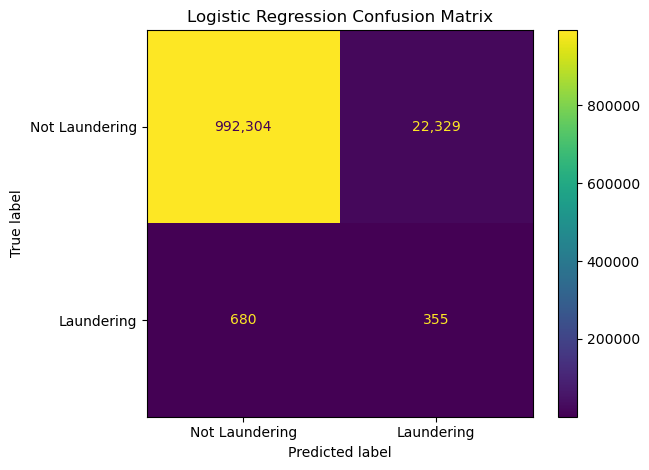

In [35]:
#Logistic Regression confusion matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(  # (scikit-learn developers, 2026
    y_test, 
    y_pred_lr,
    display_labels=[
        "Not Laundering",
        "Laundering"
    ],
    values_format=",d"
)

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

#### ROC Curve

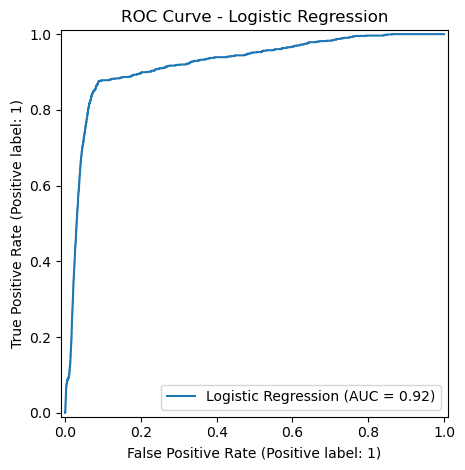

In [36]:
#Logistic Regression ROC Curve

from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name="Logistic Regression"
)

plt.title("ROC Curve - Logistic Regression")
plt.tight_layout()
plt.show()

#### Storing the results

In [37]:
# Store Logistic Regression results for final model comparison

results = []

results.append({
    "Algorithm": "Logistic Regression",
    "Accuracy": lr_accuracy,
    "Precision": lr_precision,
    "Recall": lr_recall,
    "F1-Score": lr_f1,
    "ROC-AUC": lr_roc_auc
})

results

[{'Algorithm': 'Logistic Regression',
  'Accuracy': 0.9773459437532737,
  'Precision': 0.015649797213895256,
  'Recall': 0.34299516908212563,
  'F1-Score': 0.02993380833930604,
  'ROC-AUC': 0.9201717180707272}]

##### Interpretation of Logistic Regression Results
Logistic Regression achieved an accuracy of 97.74% and ROC-AUC of 92.02%. However, the model produced substantially lower precision (1.57%), recall (34.30%) and F1-score (2.99%) for detecting money-laundering transactions. The high accuracy should be interpreted cautiously because approximately 99.90% of transactions in the original dataset belong to the non-laundering class. The recall indicates that Logistic Regression detected approximately 34% of actual laundering transactions, while the low precision indicates a considerable number of false-positive predictions. The difference between the relatively high ROC-AUC and low F1-score also suggests that model performance is sensitive to the classification threshold. Consequently, Logistic Regression provides a useful baseline against which Random Forest and Support Vector Machine can be compared.

### Random Forest

In [38]:
# Build the Random Forest pipeline

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


##### Interpretation 
Random Forest was selected as the second classification algorithm because it can capture complex and non-linear relationships between predictor variables. Random Forest is an ensemble learning method that constructs multiple decision trees and combines their predictions to improve classification performance and reduce the instability associated with individual decision trees (Breiman, 2001). Unlike Logistic Regression and SVM, Random Forest does not require numerical features to be standardised because tree-based models make predictions using feature-based decision splits. Therefore, the Random Forest preprocessing pipeline retains numerical variables in their original transformed form while applying one-hot encoding to categorical variables.

In [39]:
#Training the Random Forest model

random_forest_model.fit(
    X_train_model,
    y_train_model
)

print("Random Forest training completed successfully.")

Random Forest training completed successfully.


In [40]:
#Generating Random Forest Predictions
y_pred_rf = random_forest_model.predict(X_test)

# Probability estimates for the laundering class
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions completed.")

Random Forest predictions completed.


In [41]:
#Calculating Performance Metrics
# (scikit-learn developers, 2026)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_roc_auc:.4f}")

Random Forest Performance
-------------------------
Accuracy:  0.9805
Precision: 0.0318
Recall:    0.6164
F1-score:  0.0605
ROC-AUC:   0.9625


##### Interpretation
Random Forest was evaluated using accuracy, precision, recall, F1-score and ROC-AUC to maintain consistency with the Logistic Regression evaluation. Precision and recall are particularly important for this analysis because of the severe imbalance between legitimate and laundering transactions. Recall indicates the model's ability to identify actual laundering transactions, while precision measures how frequently transactions predicted as laundering are correctly classified (scikit-learn developers, 2026). The F1-score provides a combined assessment of precision and recall, while ROC-AUC evaluates the model's ability to distinguish between the two classes across classification thresholds.

In [42]:
# Classification Report
# (scikit-learn developers, 2026)

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "Not Laundering",
            "Laundering"
        ],
        digits=4
    )
)

                precision    recall  f1-score   support

Not Laundering     0.9996    0.9809    0.9901   1014633
    Laundering     0.0318    0.6164    0.0605      1035

      accuracy                         0.9805   1015668
     macro avg     0.5157    0.7986    0.5253   1015668
  weighted avg     0.9986    0.9805    0.9892   1015668



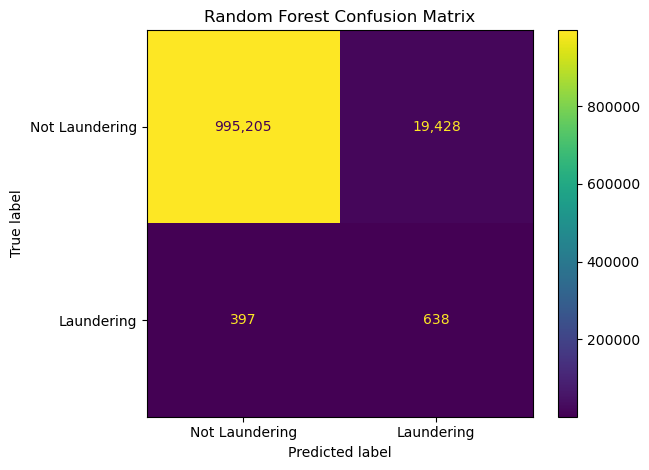

In [43]:
#Random Forest Confusion Matrix
# (scikit-learn developers, 2026)

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=[
        "Not Laundering",
        "Laundering"
    ],
    values_format=",d"
)

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

##### Interpretation
A confusion matrix was generated to examine the number of correct and incorrect predictions produced by Random Forest. The matrix distinguishes true positives, true negatives, false positives and false negatives. For AML detection, false negatives are particularly important because they represent laundering transactions that the model incorrectly classifies as legitimate.

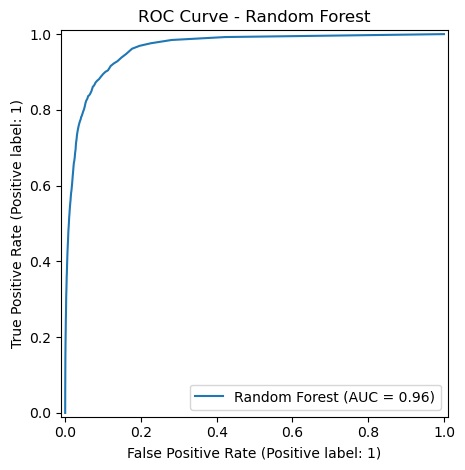

In [44]:
#Random Forest ROC Curve
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

plt.title("ROC Curve - Random Forest")
plt.tight_layout()
plt.show()

#### Random Forest Feature Importance

In [45]:
# Extract Random Forest feature importance

# Get transformed feature names
feature_names = (
    random_forest_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Extract feature importance scores
feature_importances = (
    random_forest_model
    .named_steps["classifier"]
    .feature_importances_
)

# Create DataFrame
rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

# Sort from most to least important
rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance.head(10)

,Feature,Importance
36,cat__Payment Format_ACH,0.233422
4,num__Log Amount Received,0.153027
5,num__Log Amount Paid,0.148554
1,num__To Bank,0.090600
0,num__From Bank,0.085557
2,num__Hour,0.072034
3,num__DayOfWeek,0.054751
39,cat__Payment Format_Cheque,0.038338
40,cat__Payment Format_Credit Card,0.021852
38,cat__Payment Format_Cash,0.008608


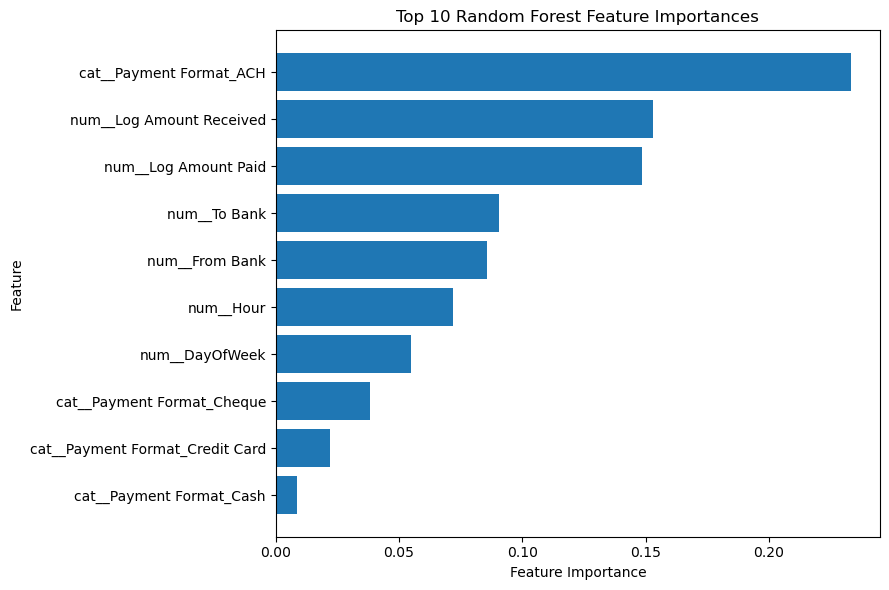

In [46]:
# Visualize the 10 most important Random Forest features

top_features = rf_importance.head(10).sort_values( # (Hunter, 2007)
    "Importance"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

##### Interpretation
Feature importance was examined to provide additional insight into the variables used by the Random Forest classifier when making predictions. The importance scores represent the relative contribution of the transformed features to reductions in decision-tree impurity. The results provide an exploratory indication of which transaction characteristics contributed most strongly to the model's classifications. However, impurity-based feature importance should not be interpreted as evidence of a causal relationship between a transaction characteristic and money laundering.

#### Store the Random Forest Results


In [47]:
#Store Random Forest results

results.append({
    "Algorithm": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1-Score": rf_f1,
    "ROC-AUC": rf_roc_auc
})

pd.DataFrame(results)

,Algorithm,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.977346,0.015650,0.342995,0.029934,0.920172
1,Random Forest,0.980481,0.031795,0.616425,0.060471,0.962521


### Support Vector Machine (SVM)

In [48]:
#Build the SVM Pipeline

from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

svm_model = Pipeline(  # (Cortes and Vapnik, 1995; scikit-learn developers, 2026)
    steps=[
        ("preprocessor", linear_preprocessor),
        (
            "classifier",
            SVC(
                kernel="rbf",
                C=1.0,
                gamma="scale",
                probability=True,
                random_state=42
            )
        )
    ]
)

svm_model

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


##### Interpretation
Support Vector Machine (SVM) was selected as the third classification algorithm for detecting money-laundering transactions. SVM constructs a decision boundary that maximises the margin between classes and can model non-linear relationships through kernel functions (Cortes and Vapnik, 1995). An RBF (Radial Basis Function) kernel was selected because it allows non-linear decision boundaries to be learned from the transaction features. Numerical features were standardised before SVM modelling because differences in feature scales can influence distance-based calculations and the resulting decision boundary. Categorical variables were one-hot encoded using the preprocessing pipeline developed previously (scikit-learn developers, 2026).

In [49]:
#Train the SVM
svm_model.fit(
    X_train_model,
    y_train_model
)

print("Support Vector Machine training completed successfully.")

Support Vector Machine training completed successfully.


In [50]:
#Generating Predictions
y_pred_svm = svm_model.predict(X_test)

# Probability estimates for laundering class
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

print("SVM predictions completed.")

SVM predictions completed.


##### Interpretation
The trained SVM classifier was applied to the same untouched test dataset used for Logistic Regression and Random Forest. Predicted class labels were generated for calculating classification metrics, while probability estimates were obtained for ROC-AUC analysis. Maintaining the same test dataset across all three algorithms ensures that their performance can be compared consistently.

In [51]:
#Calculate Performance Metrics
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)
svm_roc_auc = roc_auc_score(y_test, y_prob_svm)

print("Support Vector Machine Performance")
print("----------------------------------")
print(f"Accuracy:  {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall:    {svm_recall:.4f}")
print(f"F1-score:  {svm_f1:.4f}")
print(f"ROC-AUC:   {svm_roc_auc:.4f}")

Support Vector Machine Performance
----------------------------------
Accuracy:  0.9701
Precision: 0.0224
Recall:    0.6647
F1-score:  0.0433
ROC-AUC:   0.9184


##### Interpretation
SVM performance was evaluated using the same accuracy, precision, recall, F1-score and ROC-AUC metrics used for Logistic Regression and Random Forest. Maintaining identical evaluation measures enables a direct comparison of the three algorithms. Particular attention was given to precision, recall and F1-score because the original test dataset contains a very small proportion of laundering transactions. Accuracy alone could therefore provide an overly optimistic representation of classification performance.

In [52]:
#Classification Report
print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=[
            "Not Laundering",
            "Laundering"
        ],
        digits=4
    )
)

                precision    recall  f1-score   support

Not Laundering     0.9996    0.9704    0.9848   1014633
    Laundering     0.0224    0.6647    0.0433      1035

      accuracy                         0.9701   1015668
     macro avg     0.5110    0.8176    0.5141   1015668
  weighted avg     0.9987    0.9701    0.9839   1015668



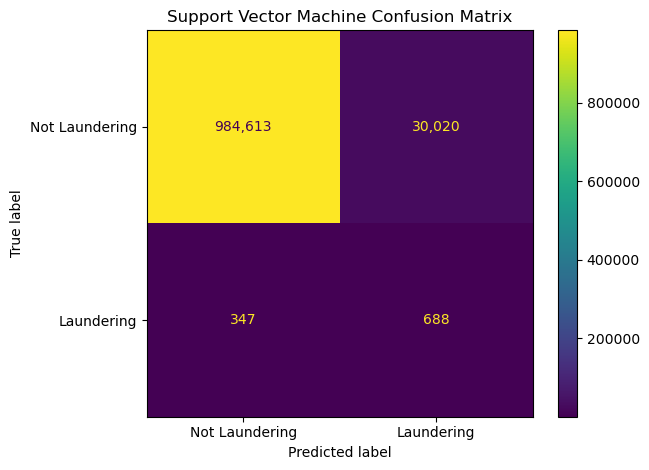

In [53]:
#SVM Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    display_labels=[
        "Not Laundering",
        "Laundering"
    ],
    values_format=",d"
)

plt.title("Support Vector Machine Confusion Matrix")
plt.tight_layout()
plt.show()

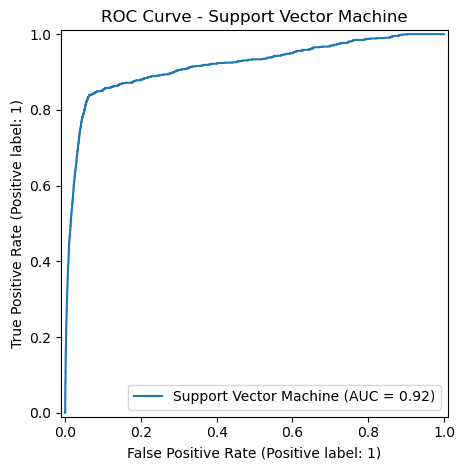

In [54]:
#SVM ROC Curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_svm,
    name="Support Vector Machine"
)

plt.title("ROC Curve - Support Vector Machine")
plt.tight_layout()
plt.show()

In [55]:
#Store SVM Results
results.append({
    "Algorithm": "Support Vector Machine",
    "Accuracy": svm_accuracy,
    "Precision": svm_precision,
    "Recall": svm_recall,
    "F1-Score": svm_f1,
    "ROC-AUC": svm_roc_auc
})

results_df = pd.DataFrame(results)

results_df

,Algorithm,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.977346,0.015650,0.342995,0.029934,0.920172
1,Random Forest,0.980481,0.031795,0.616425,0.060471,0.962521
2,Support Vector Machine,0.970101,0.022405,0.664734,0.043348,0.918446


### Model Performance Comparison

In [56]:
# Create final model performance comparison table

results_df = pd.DataFrame(results)

# Round results for presentation
comparison_table = results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

comparison_table[metric_columns] = (
    comparison_table[metric_columns] * 100
).round(2)

comparison_table

,Algorithm,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,97.73,1.56,34.30,2.99,92.02
1,Random Forest,98.05,3.18,61.64,6.05,96.25
2,Support Vector Machine,97.01,2.24,66.47,4.33,91.84


##### Interpretation
The performance of Logistic Regression, Random Forest and Support Vector Machine was compared using the same untouched test dataset. Comparative model evaluation enables differences in predictive performance between alternative machine-learning techniques to be identified and supports the selection of the most suitable model for the analytical problem (Zhou, Qiu and Zhang, 2023). For this study, Accuracy, Precision, Recall, F1-score and ROC-AUC were compared. Particular attention was given to Precision, Recall and F1-score because the IBM AML dataset is severely imbalanced, with laundering transactions representing approximately 0.102% of the original observations. Therefore, high classification accuracy alone does not necessarily demonstrate effective money-laundering detection.

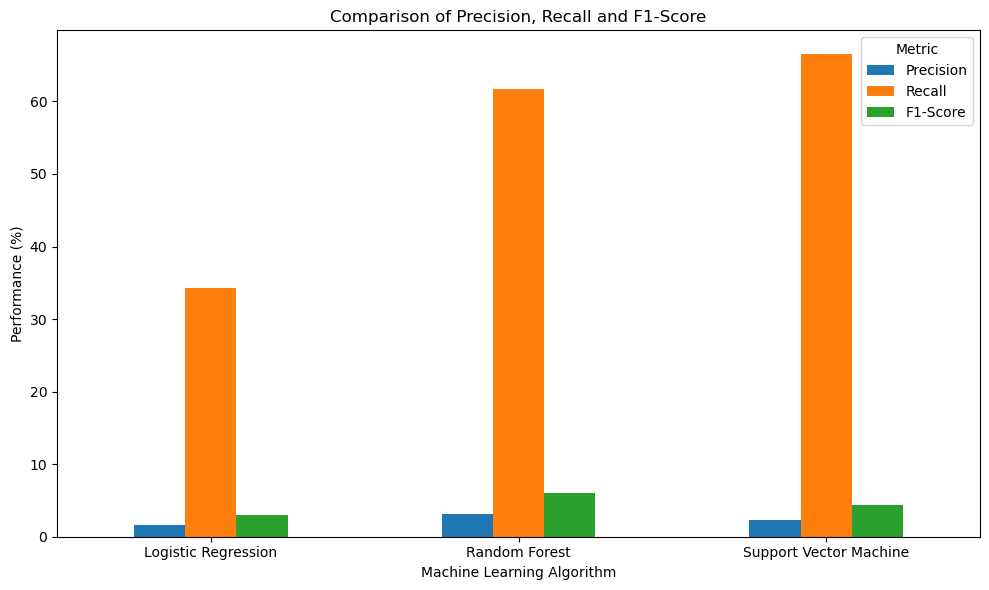

In [57]:
# Comparing Precision, Recall and F1-score

metrics_to_plot = results_df.set_index("Algorithm")[
    ["Precision", "Recall", "F1-Score"]
] * 100

ax = metrics_to_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Comparison of Precision, Recall and F1-Score"
)
plt.xlabel("Machine Learning Algorithm")
plt.ylabel("Performance (%)")

plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

##### Interpretation
Precision, Recall and F1-score were visualised to provide a direct comparison of the three classification algorithms. Precision indicates the proportion of laundering predictions that were correct, whereas Recall represents the proportion of actual laundering transactions successfully detected. F1-score provides a combined measure that balances Precision and Recall (scikit-learn developers, 2026). These metrics are particularly important in the present study because the severe target-class imbalance could otherwise cause overall accuracy to obscure poor minority-class detection.

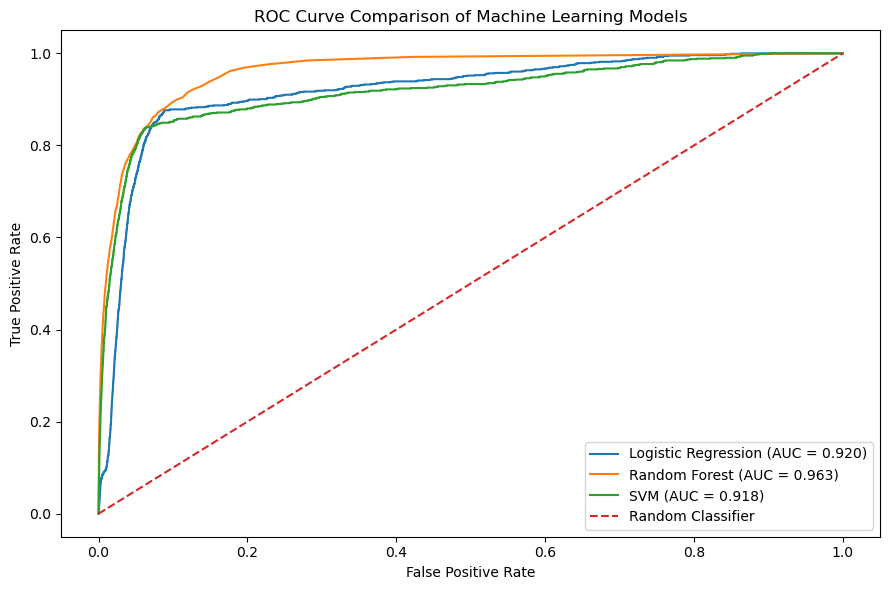

In [58]:
#Combined ROC Curve

from sklearn.metrics import roc_curve, auc

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

# SVM
fpr_svm, tpr_svm, _ = roc_curve(
    y_test,
    y_prob_svm
)

plt.figure(figsize=(9, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {lr_roc_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

plt.plot(
    fpr_svm,
    tpr_svm,
    label=f"SVM (AUC = {svm_roc_auc:.3f})"
)

# Random-classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve Comparison of Machine Learning Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.tight_layout()
plt.show()

##### Interpretation
Receiver Operating Characteristic (ROC) curves were used to compare the ability of the three algorithms to distinguish between laundering and non-laundering transactions across different classification thresholds. ROC-AUC summarises this discriminatory ability, with higher values indicating stronger separation between the two classes. The curves enable the models to be compared visually using the same test observations and classification problem.

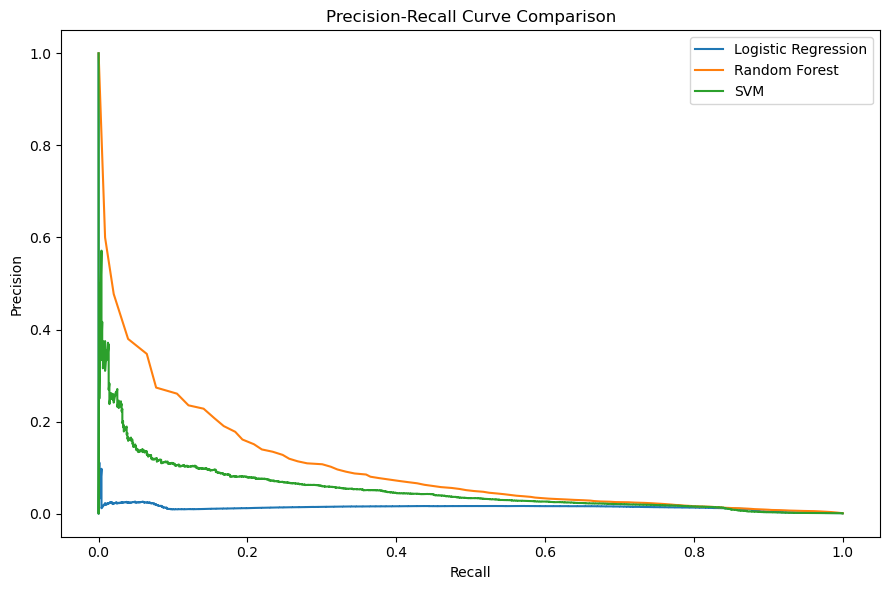

In [59]:
#Precision-Recall curve comparison

from sklearn.metrics import precision_recall_curve

# Logistic Regression
precision_lr, recall_lr, _ = precision_recall_curve(  # (scikit-learn developers, 2026)
    y_test,
    y_prob_lr
)

# Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    y_prob_rf
)

# SVM
precision_svm, recall_svm, _ = precision_recall_curve(
    y_test,
    y_prob_svm
)

plt.figure(figsize=(9, 6))

plt.plot(
    recall_lr,
    precision_lr,
    label="Logistic Regression"
)

plt.plot(
    recall_rf,
    precision_rf,
    label="Random Forest"
)

plt.plot(
    recall_svm,
    precision_svm,
    label="SVM"
)

plt.title(
    "Precision-Recall Curve Comparison"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()
plt.tight_layout()
plt.show()

##### Interpretation
Precision-Recall curves were additionally examined because the positive laundering class represents only a very small proportion of the test dataset. Precision-Recall analysis focuses directly on the relationship between correctly detecting positive observations and limiting false-positive classifications. This provides an additional perspective on model performance under severe class imbalance.

In [62]:
#Calculating Average Precision (AP) so that PR Curves could have numerical summary
from sklearn.metrics import average_precision_score

ap_lr = average_precision_score(y_test, y_prob_lr)
ap_rf = average_precision_score(y_test, y_prob_rf)
ap_svm = average_precision_score(y_test, y_prob_svm)

print(f"Logistic Regression AP: {ap_lr:.4f}")
print(f"Random Forest AP:       {ap_rf:.4f}")
print(f"SVM AP:                 {ap_svm:.4f}")

Logistic Regression AP: 0.0140
Random Forest AP:       0.0942
SVM AP:                 0.0532


In [60]:
#Confusion Matrix Comparison

from sklearn.metrics import confusion_matrix

models_predictions = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm
}

confusion_results = []

for model_name, predictions in models_predictions.items():

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    confusion_results.append({
        "Algorithm": model_name,
        "True Positives": tp,
        "False Positives": fp,
        "True Negatives": tn,
        "False Negatives": fn
    })

confusion_df = pd.DataFrame(confusion_results)

confusion_df

,Algorithm,True Positives,False Positives,True Negatives,False Negatives
0,Logistic Regression,355,22329,992304,680
1,Random Forest,638,19428,995205,397
2,SVM,688,30020,984613,347


In [61]:
#Identifying the Best Performing Model
print(
    "Highest Accuracy:",
    results_df.loc[
        results_df["Accuracy"].idxmax(),
        "Algorithm"
    ]
)

print(
    "Highest Precision:",
    results_df.loc[
        results_df["Precision"].idxmax(),
        "Algorithm"
    ]
)

print(
    "Highest Recall:",
    results_df.loc[
        results_df["Recall"].idxmax(),
        "Algorithm"
    ]
)

print(
    "Highest F1-Score:",
    results_df.loc[
        results_df["F1-Score"].idxmax(),
        "Algorithm"
    ]
)

print(
    "Highest ROC-AUC:",
    results_df.loc[
        results_df["ROC-AUC"].idxmax(),
        "Algorithm"
    ]
)

Highest Accuracy: Random Forest
Highest Precision: Random Forest
Highest Recall: Support Vector Machine
Highest F1-Score: Random Forest
Highest ROC-AUC: Random Forest


##### Interpretation of Model Performance Comparison
The comparative evaluation demonstrates clear differences between Logistic Regression, Random Forest and Support Vector Machine (SVM). Random Forest achieved the strongest overall performance, recording the highest accuracy (98.05%), precision (3.18%), F1-score (6.05%), and ROC-AUC (96.25%). The ROC-AUC result indicates that Random Forest provided the strongest overall ability to distinguish between laundering and non-laundering transactions across different classification thresholds. Comparative evaluation of multiple machine-learning approaches is useful for determining which modelling technique provides the most appropriate predictive performance for a specific analytical problem (Zhou, Qiu and Zhang, 2023).

SVM achieved the highest recall of 66.47%, correctly identifying 688 laundering transactions and producing 347 false negatives. Random Forest achieved slightly lower recall of 61.64%, detecting 638 laundering transactions with 397 false negatives. Logistic Regression performed considerably worse in detecting the minority class, achieving recall of only 34.30% and producing 680 false negatives. These results demonstrate why accuracy alone is insufficient for evaluating the models, particularly given the substantial class imbalance within the dataset.

A trade-off was also observed between SVM and Random Forest. Although SVM detected the greatest number of laundering transactions, it generated 30,020 false-positive alerts, compared with 19,428 for Random Forest. Random Forest therefore provided a stronger balance between identifying laundering transactions and limiting false-positive classifications. This is reflected in its higher precision and F1-score. Logistic Regression generated 22,329 false positives while detecting substantially fewer laundering transactions than either Random Forest or SVM.

Overall, Random Forest was identified as the strongest-performing model because it achieved the highest performance across four of the five evaluation metrics while maintaining substantially higher laundering detection than Logistic Regression. However, SVM demonstrated the highest sensitivity to laundering transactions, indicating that it may be preferable where maximising the detection of potentially illicit transactions is prioritised over reducing false-positive alerts.